In [4]:
from google.colab import files
uploaded=files.upload()

Saving Bird Speciees Dataset.zip to Bird Speciees Dataset.zip


In [5]:
import zipfile
import os
zip_path="/content/Bird Speciees Dataset.zip"
extract_path="/content"

with zipfile.ZipFile(zip_path,'r')as zip_ref:
  zip_ref.extractall(extract_path)

print("extraction completed")


extraction completed


In [6]:
import numpy as numpy
import matplotlib.pyplot as plt
import tensorflow as tf
# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report

# Visualization
import seaborn as sns

In [7]:
# Data Preprocessing
image_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [8]:
# Load Dataset
train_generator = datagen.flow_from_directory(
    '/content/Bird Speciees Dataset',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    '/content/Bird Speciees Dataset',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 652 images belonging to 6 classes.
Found 159 images belonging to 6 classes.


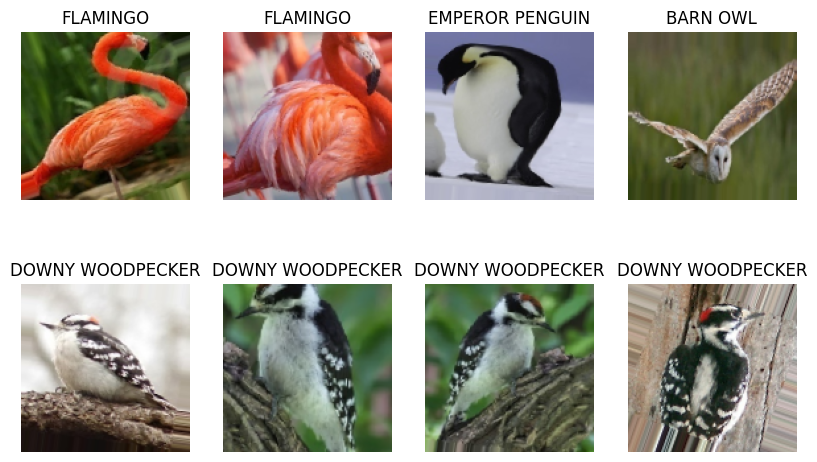

In [9]:
import numpy as np
# Visualize Data
images, labels = next(train_generator)

class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(10, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')

plt.show()

In [10]:
# MLP Model (Baseline)
mlp_model = Sequential([
    Flatten(input_shape=(128, 128, 3)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(train_generator.num_classes, activation='softmax')
])

mlp_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
#train nlp
# Train NLP model
import nltk
nlp_history = mlp_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30
)

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 319ms/step - accuracy: 0.2439 - loss: 10.0208 - val_accuracy: 0.2830 - val_loss: 3.0179
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 353ms/step - accuracy: 0.4248 - loss: 1.6881 - val_accuracy: 0.4465 - val_loss: 1.4899
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 269ms/step - accuracy: 0.4525 - loss: 2.0255 - val_accuracy: 0.3270 - val_loss: 2.5097
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 314ms/step - accuracy: 0.4847 - loss: 1.8329 - val_accuracy: 0.4465 - val_loss: 1.6613
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.5092 - loss: 1.5331 - val_accuracy: 0.5157 - val_loss: 1.3611
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 296ms/step - accuracy: 0.5307 - loss: 1.5043 - val_accuracy: 0.5157 - val_loss: 1.2752
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 287ms/step - accuracy: 0.6043 - loss: 1.1560 - val_accuracy: 0.5409 - val_loss: 1.3628
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 259ms/step - accuracy: 0.5782 - loss: 1.2740 - val_accuracy: 0

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, generator, model_name):
    print(f"\n===== {model_name} Evaluation =====")

    # Accuracy
    loss, acc = model.evaluate(generator, verbose=0)
    print(f"Accuracy: {acc*100:.2f}%")

    # Predictions
    y_pred = model.predict(generator)
    y_pred = np.argmax(y_pred, axis=1)
    y_true = generator.classes

    labels = list(generator.class_indices.keys())

    images_labels=next(train_generator)
    class_names=list(generator.class_indices.keys())
   # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d',
                cmap='Blues',
                xticklabels=labels,
                yticklabels=labels)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=labels))






===== MLP Model Evaluation =====
Accuracy: 71.07%
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step


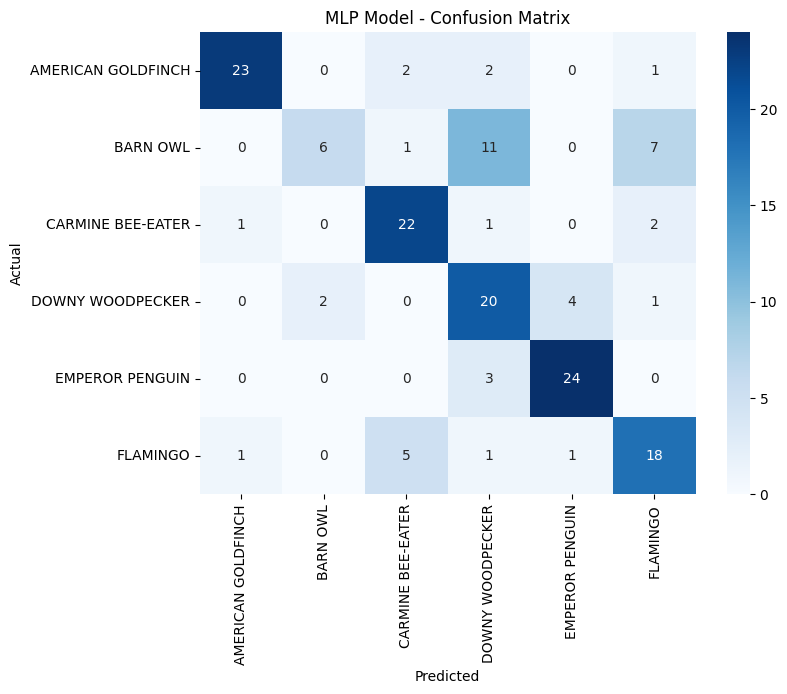


Classification Report:
                    precision    recall  f1-score   support

AMERICAN GOLDFINCH       0.92      0.82      0.87        28
          BARN OWL       0.75      0.24      0.36        25
 CARMINE BEE-EATER       0.73      0.85      0.79        26
  DOWNY WOODPECKER       0.53      0.74      0.62        27
   EMPEROR PENGUIN       0.83      0.89      0.86        27
          FLAMINGO       0.62      0.69      0.65        26

          accuracy                           0.71       159
         macro avg       0.73      0.70      0.69       159
      weighted avg       0.73      0.71      0.70       159



In [13]:
evaluate_model(mlp_model,val_generator,"MLP Model")

In [14]:
# 7. CNN Model
cnn_model = Sequential([
    Conv2D(32,(3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

# Convolution = feature extraction
# Filters = edge detectors
# Pooling = size reduction
# Dropout = overfitting prevention

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
#Train CNN
cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

cnn_history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.2423 - loss: 2.1461 - val_accuracy: 0.5220 - val_loss: 1.4146
Epoch 2/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.5383 - loss: 1.2052 - val_accuracy: 0.6855 - val_loss: 0.9019
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.6933 - loss: 0.8960 - val_accuracy: 0.7673 - val_loss: 0.6560
Epoch 4/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.7239 - loss: 0.7215 - val_accuracy: 0.8239 - val_loss: 0.5318
Epoch 5/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.7991 - loss: 0.5628 - val_accuracy: 0.8616 - val_loss: 0.4033
Epoch 6/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.8175 - loss: 0.5016 - val_accuracy: 0.8365 - val_loss: 0.4614
Epoch 7/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8758 - loss: 0.3904 - val_accuracy: 0.8805 - val_loss: 0.3284
Epoch 8/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8313 - loss: 0.4737 - val_accuracy: 0.8616 - val_loss:


===== CNN Model Evaluation =====
Accuracy: 89.94%
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 388ms/step


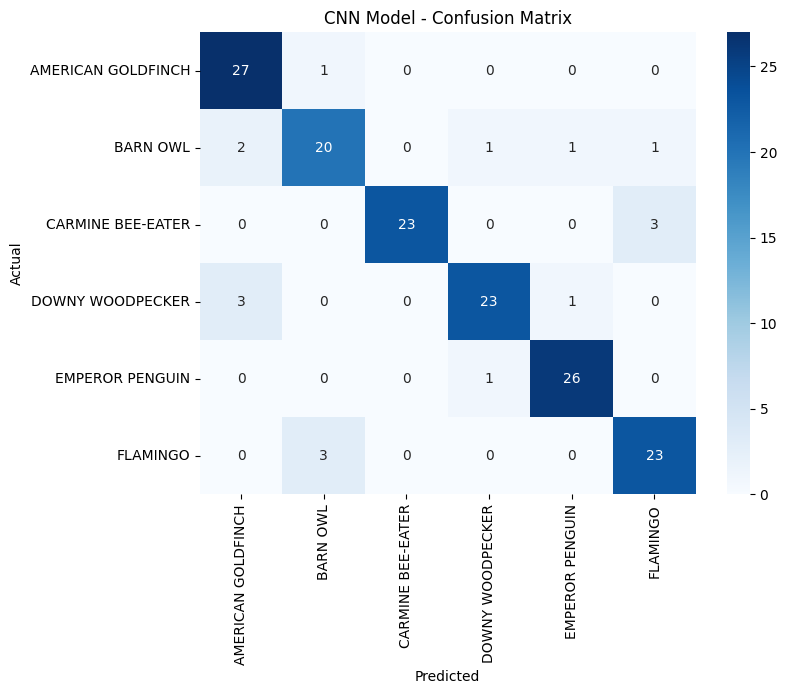


Classification Report:
                    precision    recall  f1-score   support

AMERICAN GOLDFINCH       0.84      0.96      0.90        28
          BARN OWL       0.83      0.80      0.82        25
 CARMINE BEE-EATER       1.00      0.88      0.94        26
  DOWNY WOODPECKER       0.92      0.85      0.88        27
   EMPEROR PENGUIN       0.93      0.96      0.95        27
          FLAMINGO       0.85      0.88      0.87        26

          accuracy                           0.89       159
         macro avg       0.90      0.89      0.89       159
      weighted avg       0.90      0.89      0.89       159



In [16]:
evaluate_model(cnn_model,val_generator,"CNN Model")

In [17]:
#Transferred learning---Mobilenet, Resnet, Vgg16 (pretrained cnn models for image classification)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
#Transfer Learning
base_model = MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128,activation='relu')(x)
output = Dense(train_generator.num_classes,activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [18]:
#Train Transfer Model
transfer_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

transfer_history = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 24s 823ms/step - accuracy: 0.8359 - loss: 0.5072 - val_accuracy: 0.9874 - val_loss: 0.0470
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 716ms/step - accuracy: 0.9954 - loss: 0.0194 - val_accuracy: 0.9937 - val_loss: 0.0143
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 743ms/step - accuracy: 0.9985 - loss: 0.0069 - val_accuracy: 0.9937 - val_loss: 0.0194
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 848ms/step - accuracy: 0.9985 - loss: 0.0074 - val_accuracy: 0.9937 - val_loss: 0.0114
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 691ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 0.9937 - val_loss: 0.0301
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 718ms/step - accuracy: 0.9985 - loss: 0.0063 - val_accuracy: 0.9937 - val_loss: 0.0318
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 712ms/step - accuracy: 0.9985 - loss: 0.0038 - val_accuracy: 0.9874 - val_loss: 0.0319
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 736ms/step - accuracy: 1.0000 - loss: 0.0046 - val_accu


===== MobileNetV2 Model Evaluation =====
Accuracy: 100.00%
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 501ms/step


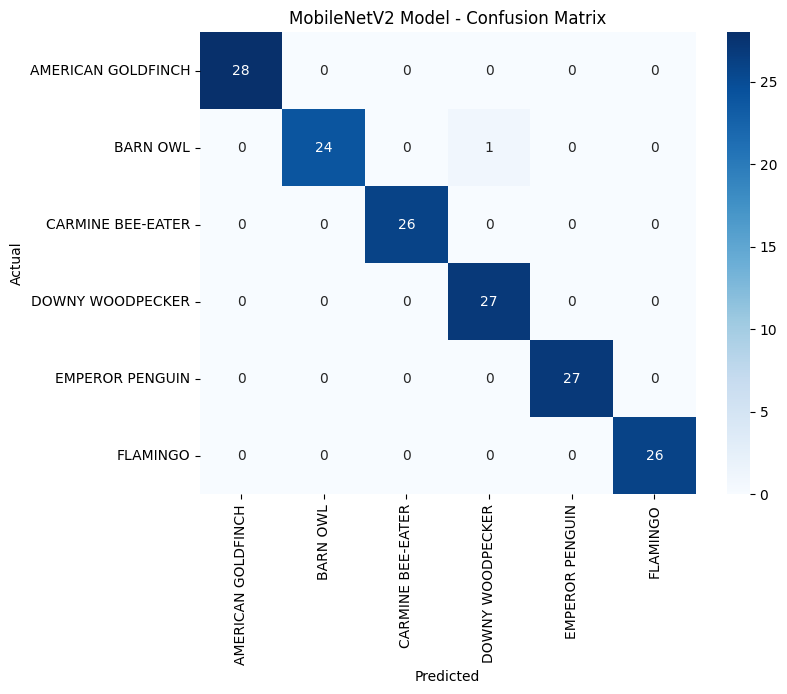


Classification Report:
                    precision    recall  f1-score   support

AMERICAN GOLDFINCH       1.00      1.00      1.00        28
          BARN OWL       1.00      0.96      0.98        25
 CARMINE BEE-EATER       1.00      1.00      1.00        26
  DOWNY WOODPECKER       0.96      1.00      0.98        27
   EMPEROR PENGUIN       1.00      1.00      1.00        27
          FLAMINGO       1.00      1.00      1.00        26

          accuracy                           0.99       159
         macro avg       0.99      0.99      0.99       159
      weighted avg       0.99      0.99      0.99       159



In [23]:
evaluate_model(transfer_model,val_generator,"MobileNetV2 Model")

In [24]:
mlp_model.save("mlp_flower_model.h5")
cnn_model.save("cnn_flower_model.h5")
transfer_model.save("mobilenetv2_bird_model.h5")

In [25]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

model = load_model("mobilenetv2_bird_model.h5")

def predict_image(model, img_path, class_indices):

    img = image.load_img(img_path, target_size=(128,128))
    img = image.img_to_array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    idx = np.argmax(pred)

    labels = {v:k for k,v in class_indices.items()}

    print("Prediction:", labels[idx])
    print("Confidence:", pred[0][idx])

In [30]:
predict_image(model,"Bird Speciees Dataset/AMERICAN GOLDFINCH/002.jpg",val_generator.class_indices)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Prediction: AMERICAN GOLDFINCH
Confidence: 0.99999833
